**Why this notebook auto-reloads code**

The next cell enables IPython’s `autoreload` so changes you make in the `netsci` module are picked up automatically before each cell runs, without restarting the kernel.

Reference: https://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython


In [ ]:
# Auto-reload netsci modules if code changes
%uv sync
%load_ext autoreload
%autoreload 2

Note: you may need to restart the kernel to use updated packages.
The autoreload module is not an IPython extension.


Resolved 119 packages in 1ms
Audited 116 packages in 5ms
UsageError: Line magic function `%autoreload` not found.


# Week 1: Introduction to Networks

**Learning objectives** — After this lab you should be able to:

- Explain what nodes and edges represent in a network
- Build a small graph from scratch with NetworkX
- Distinguish directed, undirected, and weighted graphs
- Load real-world datasets and inspect basic properties
- Visualize networks with different layouts and coloring

Networks are everywhere — social media friendships, airline routes, protein interactions, the web itself.
In this first lab we will learn the vocabulary of **graph theory** and get hands-on with NetworkX,
the Python library we will use throughout the course.

## 0. Environment Smoke Test

Run the cell below to verify your environment is set up correctly.

In [2]:
# === Environment Smoke Test ===
# Run this cell first. If it passes, your environment is correctly set up.
# If it fails, follow the error message instructions.

def _smoke_test():
    """Validate that all required packages are installed and importable."""
    import sys

    errors = []

    # Check Python version
    if sys.version_info < (3, 12):
        errors.append(
            f"Python >= 3.12 required, but you have {sys.version}.\n"
            f"  Fix: run 'uv sync' from the repository root to set up the correct environment."
        )

    # Check required packages and minimum versions
    checks = [
        ("networkx", "nx", "3.6"),
        ("matplotlib", "matplotlib", "3.10"),
        ("numpy", "np", "2.2"),
        ("scipy", "scipy", "1.14"),
        ("pandas", "pd", "2.2"),
        ("seaborn", "sns", "0.13"),
        ("pyvis", "pyvis", "0.3"),
        ("ipywidgets", "ipywidgets", "8.1"),
    ]

    for package_name, import_name, min_version in checks:
        try:
            mod = __import__(package_name)
            version = getattr(mod, "__version__", "0.0.0")
            # Compare major.minor only
            installed = tuple(int(x) for x in version.split(".")[:2])
            required = tuple(int(x) for x in min_version.split(".")[:2])
            if installed < required:
                errors.append(
                    f"{package_name} >= {min_version} required, but {version} is installed.\n"
                    f"  Fix: run 'uv sync' from the repository root."
                )
        except ImportError:
            errors.append(
                f"{package_name} is not installed.\n"
                f"  Fix: run 'uv sync' from the repository root."
            )

    # Check netsci package
    try:
        import netsci
    except ImportError:
        errors.append(
            "The 'netsci' package is not installed.\n"
            "  Fix: run 'uv sync' from the repository root.\n"
            "  This installs the course's shared utilities package."
        )

    if errors:
        print("ENVIRONMENT CHECK FAILED")
        print("=" * 50)
        for i, error in enumerate(errors, 1):
            print(f"\n  {i}. {error}")
        print("\n" + "=" * 50)
        print("Run 'uv sync' in your terminal, then restart the kernel and try again.")
        raise SystemExit(1)
    else:
        import networkx as nx

        print("Environment check passed!")
        print(f"  Python:    {sys.version.split()[0]}")
        print(f"  NetworkX:  {nx.__version__}")
        print(f"  netsci:    {netsci.__version__}")
        print("You're ready to start the lab.")


_smoke_test()
del _smoke_test  # clean up namespace


Environment check passed!
  Python:    3.12.0
  NetworkX:  3.6
  netsci:    0.1.0
You're ready to start the lab.


In [3]:
import networkx as nx

from netsci import viz
from netsci.loaders import load_graph
from netsci.utils import graph_summary

---
## 1. What is a Graph?

Think of a social network: **people** are *nodes* (also called *vertices*) and **friendships** are *edges* (also called *links*).
That's all a graph is — a collection of nodes connected by edges.

Let's build one from scratch.

In [4]:
# Build a small friendship network from scratch
G = nx.Graph()
G.add_nodes_from(["Alice", "Bob", "Carol", "Dave", "Eve"])

G.add_edge("Alice", "Bob")
G.add_edge("Alice", "Carol")
G.add_edge("Bob", "Carol")
G.add_edge("Bob", "Dave")
G.add_edge("Dave", "Eve")

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Nodes: ['Alice', 'Bob', 'Carol', 'Dave', 'Eve']
Edges: [('Alice', 'Bob'), ('Alice', 'Carol'), ('Bob', 'Carol'), ('Bob', 'Dave'), ('Dave', 'Eve')]
Number of nodes: 5
Number of edges: 5


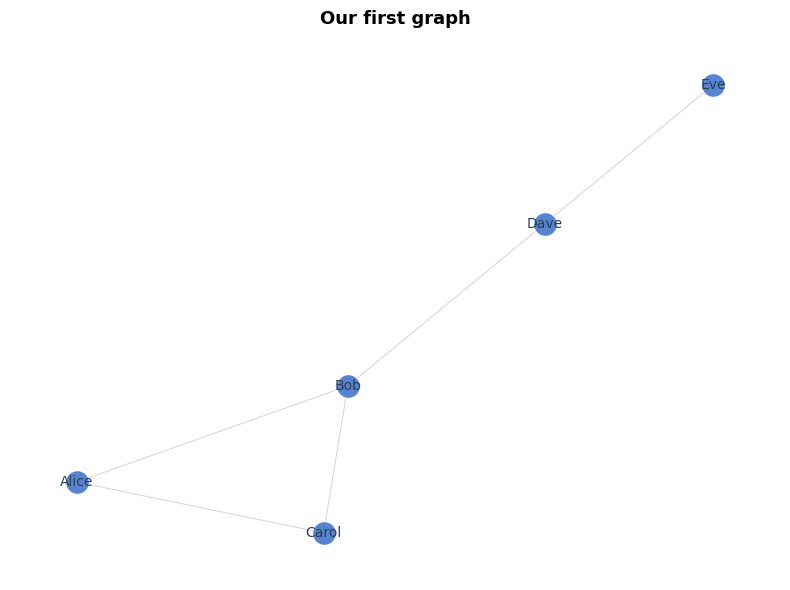

In [5]:
viz.draw_graph(G, title="Our first graph")

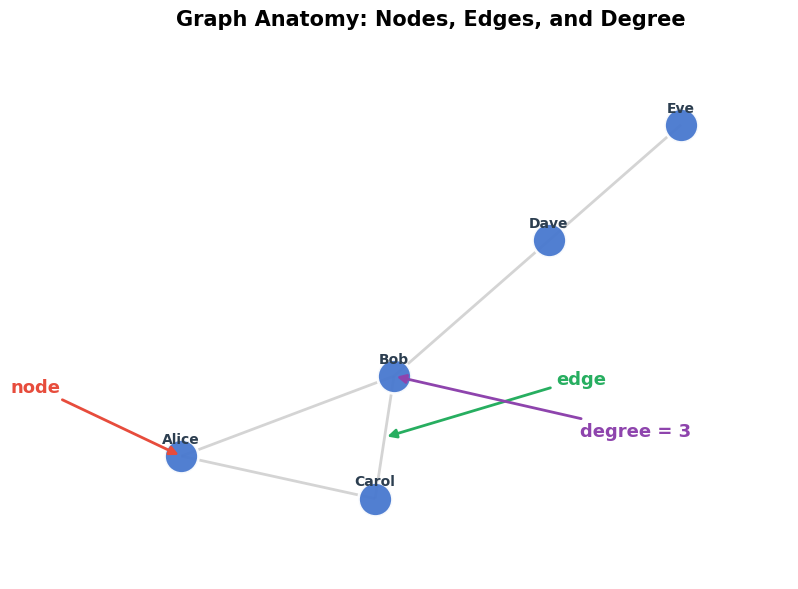

In [6]:
# Annotated diagram — labels the three key concepts: node, edge, degree
viz.draw_graph_anatomy(G)

Each circle is a node, each line is an edge.  Notice that Alice, Bob, and Carol form a **triangle** — they are all friends with each other.

---
## 2. Directed vs. Undirected Graphs

On **Facebook**, friendship goes both ways — if Alice is friends with Bob, Bob is also friends with Alice. That's an *undirected* graph.

On **Twitter/X**, you can follow someone without them following you back. That's a *directed* graph — edges have arrows.

In [7]:
# A directed "follows" graph — edges have direction (A → B ≠ B → A)
D = nx.DiGraph()
D.add_edge("Alice", "Bob")  # Alice follows Bob
D.add_edge("Bob", "Alice")  # Bob follows back (mutual)
D.add_edge("Carol", "Alice")  # Carol follows Alice (one-way)
D.add_edge("Carol", "Bob")
D.add_edge("Dave", "Alice")

print("Is directed?", D.is_directed())
print()

# In directed graphs every node has an in-degree AND an out-degree
for node in D.nodes():
    print(f"{node}: in-degree={D.in_degree(node)}, out-degree={D.out_degree(node)}")

Is directed? True

Alice: in-degree=3, out-degree=1
Bob: in-degree=2, out-degree=1
Carol: in-degree=0, out-degree=2
Dave: in-degree=0, out-degree=1


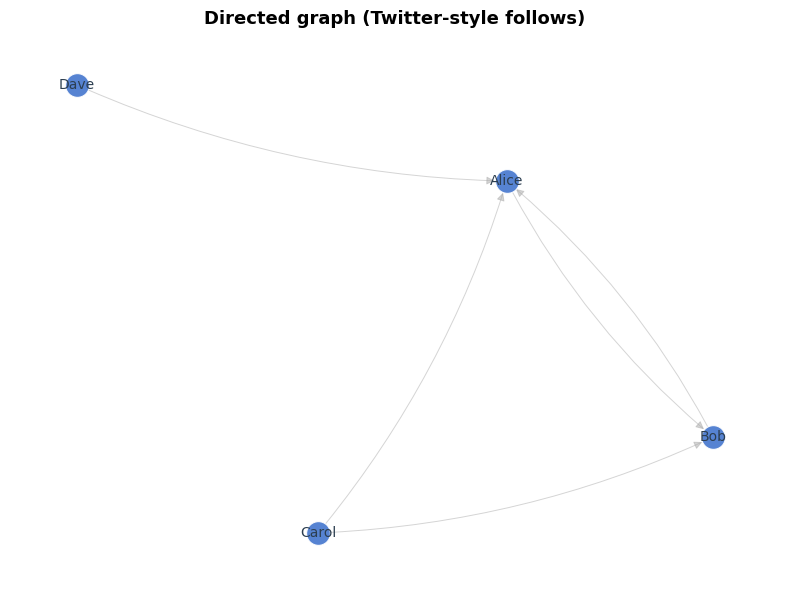

In [8]:
viz.draw_graph(D, title="Directed graph (Twitter-style follows)")

Alice has a high **in-degree** (many followers) but a low **out-degree** (she follows few people). In directed networks, popularity and activity are different things.

### Real-World Directed Network: Email Communication

The toy example above illustrates the concept, but directed networks are most interesting at scale.
Let's load the EU email dataset — 1,005 employees, 25,571 emails — and explore how in-degree and out-degree tell different stories.

In [11]:
# EU email communication network — 1,005 employees, 25,571 directed edges
G_email = load_graph("email")
graph_summary(G_email)

print(f"\nIs directed? {G_email.is_directed()}")
print(f"Nodes: {G_email.number_of_nodes()}, Edges: {G_email.number_of_edges()}")

email: 1005 nodes, 25571 edges (directed)
Graph Summary: Graph
  Type:        directed
  Nodes:       1005
  Edges:       25571
  Density:     0.0253
  Avg degree:  50.89
  Components:  20

Is directed? True
Nodes: 1005, Edges: 25571


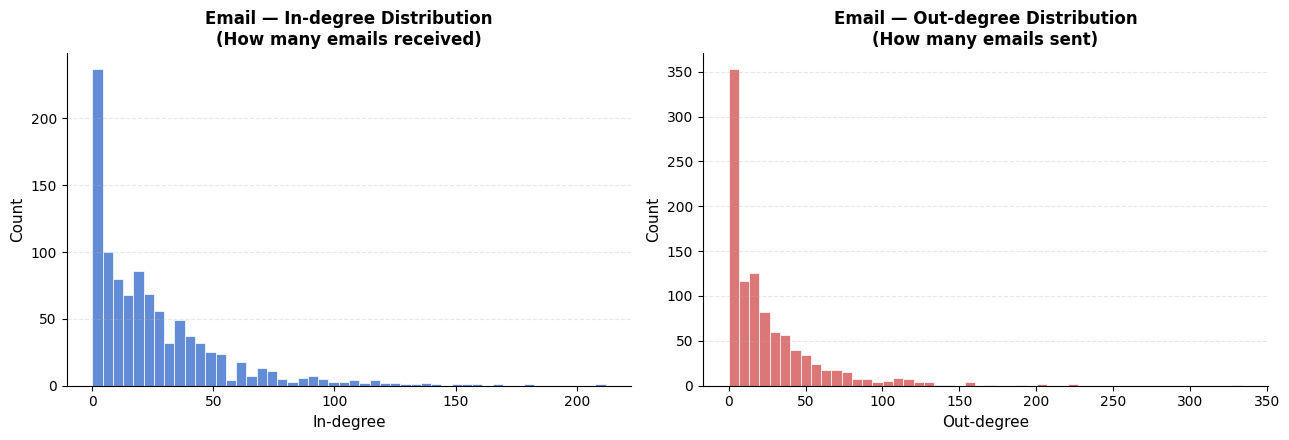

In [12]:
# Compare in-degree (emails received) vs out-degree (emails sent)
viz.plot_in_out_degree(G_email, title_prefix="Email")

In [13]:
# Find nodes where in-degree and out-degree differ sharply
nodes = list(G_email.nodes())
in_deg = dict(G_email.in_degree())
out_deg = dict(G_email.out_degree())

# "Popular recipients" — receive many emails but rarely reply
high_in_low_out = [
    (n, in_deg[n], out_deg[n]) for n in nodes if in_deg[n] > 50 and out_deg[n] < 20
]
high_in_low_out.sort(key=lambda x: x[1], reverse=True)

print("High in-degree, low out-degree (popular recipients):")
for n, ind, outd in high_in_low_out[:5]:
    print(f"  Node {n}: in={ind}, out={outd}")

# "Prolific senders" — send many emails but rarely receive
high_out_low_in = [
    (n, in_deg[n], out_deg[n]) for n in nodes if out_deg[n] > 50 and in_deg[n] < 20
]
high_out_low_in.sort(key=lambda x: x[2], reverse=True)

print("\nHigh out-degree, low in-degree (prolific senders):")
for n, ind, outd in high_out_low_in[:5]:
    print(f"  Node {n}: in={ind}, out={outd}")

High in-degree, low out-degree (popular recipients):
  Node 365: in=90, out=2
  Node 208: in=52, out=9
  Node 1: in=51, out=1

High out-degree, low in-degree (prolific senders):
  Node 971: in=10, out=94


### Weakly vs Strongly Connected Components

In directed graphs, connectivity has two flavors:
- **Weakly connected**: there is a path between every pair of nodes *if we ignore edge directions*
- **Strongly connected**: there is a directed path from every node to every other node (following arrows)

A strongly connected component is a much stricter requirement — it means information can flow in *both* directions between every pair.

In [14]:
# Weakly connected = path exists ignoring direction; strongly = following arrows
n_weak = nx.number_weakly_connected_components(G_email)
n_strong = nx.number_strongly_connected_components(G_email)
largest_scc = max(nx.strongly_connected_components(G_email), key=len)

print(f"Weakly connected components:  {n_weak}")
print(f"Strongly connected components: {n_strong}")
print(
    f"Largest SCC: {len(largest_scc)} nodes "
    f"({len(largest_scc) / G_email.number_of_nodes():.0%} of network)"
)

print("\nThe gap tells us: most nodes can be reached (weakly), but")
print("reciprocal communication paths are rarer (strongly).")

Weakly connected components:  20
Strongly connected components: 203
Largest SCC: 803 nodes (80% of network)

The gap tells us: most nodes can be reached (weakly), but
reciprocal communication paths are rarer (strongly).


---
## 2.5 Bipartite Networks (a brief look)

Some networks naturally have **two types of nodes**. Movies and actors. Papers and authors. Customers and products. These are **bipartite** (or "two-mode") networks — edges only connect nodes of *different* types.

Let's build a tiny example.

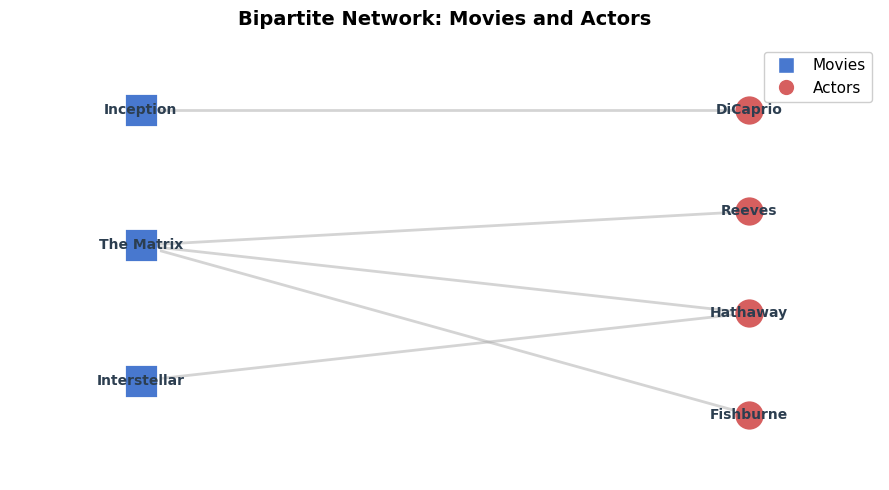

In [15]:
# Build a tiny bipartite graph: movies ↔ actors
B = nx.Graph()

movies = ["Inception", "The Matrix", "Interstellar"]
actors = ["DiCaprio", "Reeves", "Hathaway", "Fishburne"]

B.add_nodes_from(movies, bipartite=0)
B.add_nodes_from(actors, bipartite=1)

B.add_edges_from(
    [
        ("DiCaprio", "Inception"),
        ("Hathaway", "Interstellar"),
        ("Hathaway", "The Matrix"),
        ("Reeves", "The Matrix"),
        ("Fishburne", "The Matrix"),
    ]
)

viz.draw_bipartite(
    B,
    top_nodes=movies,
    bottom_nodes=actors,
    title="Bipartite Network: Movies and Actors",
    top_label="Movies",
    bottom_label="Actors",
)

Actor co-starring network (projected from bipartite):
  Fishburne -- Hathaway  (shared: {'The Matrix'})
  Fishburne -- Reeves  (shared: {'The Matrix'})
  Hathaway -- Reeves  (shared: {'The Matrix'})

Isolated nodes (no connections): ['DiCaprio']


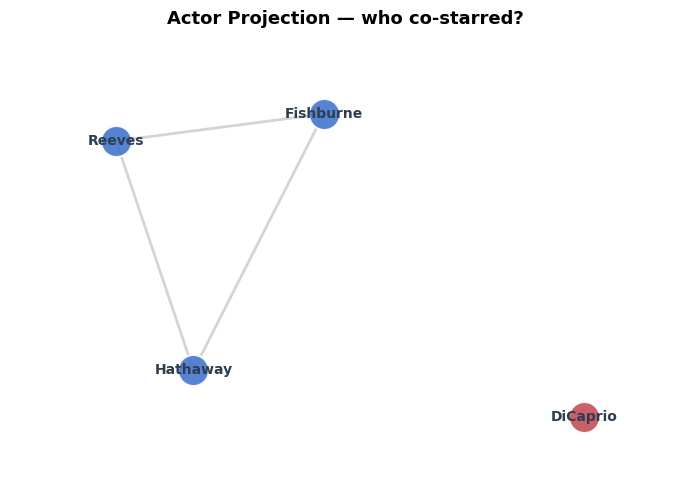

In [16]:
# One-mode projection: collapse bipartite → actors linked by shared movies
actor_set = {n for n, d in B.nodes(data=True) if d["bipartite"] == 1}
G_actors = nx.bipartite.projected_graph(B, actor_set)

print("Actor co-starring network (projected from bipartite):")
viz.draw_projection(G_actors, bipartite_G=B, title="Actor Projection — who co-starred?")

**What the projection tells us:** Reeves, Hathaway, and Fishburne form a **triangle** because they all appeared in *The Matrix* — the projection turns every shared movie into an edge, so actors from the same film become a **clique**. DiCaprio is **isolated** (red node) because he is the only actor in *Inception* in this dataset, so the projection gives him no co-star edges. This illustrates the key trade-off of one-mode projections: you gain a simpler, single-type network, but you lose the bipartite structure that explains *why* edges exist.

**Many real networks are secretly bipartite.** Co-authorship networks (papers × authors), product recommendation networks (users × items), and even board-of-directors networks (companies × people) all start as two-mode graphs. The "one-mode projection" collapses them into a single-type network — but information is lost in the process. Keep this in mind when you encounter a dense network: it may be the projection of a simpler bipartite structure.

**Looking ahead**: The projection above creates implicit communities — actors who share many movies form tight clusters. In Week 5 we will learn algorithms that detect such communities automatically. And the dense triangles that projections create inflate the clustering coefficient (Week 2) — a useful reminder that network properties depend on how the data was constructed.

---
## 3. Weighted Graphs

Sometimes edges carry extra information. In a co-appearance network, the **weight** of an edge tells us how many times two characters appeared together.

**Dataset**: The *Les Miserables* co-appearance network was compiled by Donald Knuth (1993) from Victor Hugo's novel. Each **node** is a character, each **edge** means two characters appeared in the same chapter, and the **weight** counts how many chapters they co-appeared in. It is a classic benchmark because it has clear community structure (the subplots of the novel) and a dominant hub (Jean Valjean).

In [17]:
# A small weighted graph — the "weight" records how often two people met
W = nx.Graph()
W.add_edge("Alice", "Bob", weight=5)  # met 5 times
W.add_edge("Alice", "Carol", weight=2)  # met 2 times
W.add_edge("Bob", "Carol", weight=8)  # met 8 times

for u, v, data in W.edges(data=True):
    print(f"{u} -- {v}  weight={data['weight']}")

Alice -- Bob  weight=5
Alice -- Carol  weight=2
Bob -- Carol  weight=8


In [18]:
G_les = load_graph("lesmis")
graph_summary(G_les)

lesmis: 77 nodes, 254 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       77
  Edges:       254
  Density:     0.0868
  Avg degree:  6.60
  Components:  1
  Avg clustering: 0.5731


In [19]:
# Inspect the heaviest edges — which characters co-appear most?
edges_with_weight = [(u, v, d["weight"]) for u, v, d in G_les.edges(data=True)]
edges_with_weight.sort(key=lambda x: x[2], reverse=True)

print("Top 5 strongest connections:")
for u, v, w in edges_with_weight[:5]:
    print(f"  {u} -- {v}: weight = {w}")

Top 5 strongest connections:
  Valjean -- Cosette: weight = 31
  Cosette -- Marius: weight = 21
  Valjean -- Marius: weight = 19
  Valjean -- Javert: weight = 17
  Enjolras -- Courfeyrac: weight = 17


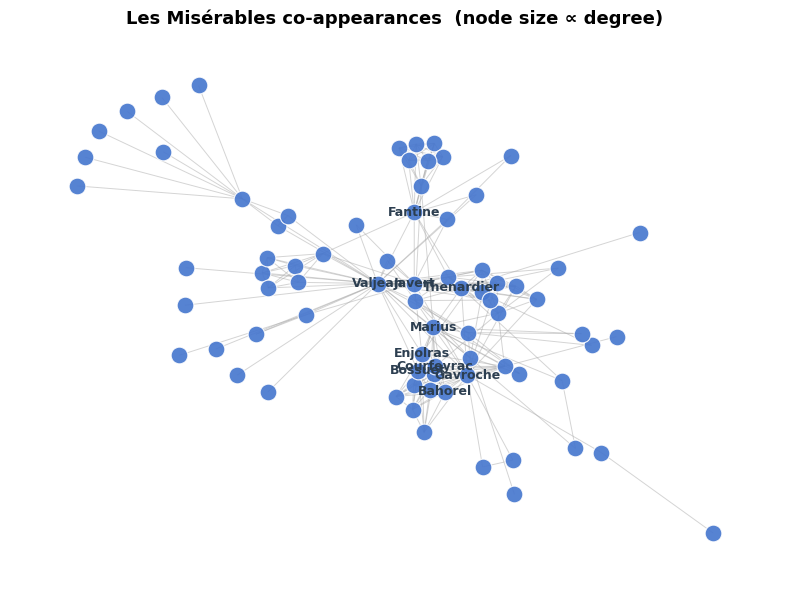

In [20]:
# Node size ∝ degree — bigger nodes have more co-appearances
viz.draw_graph(
    G_les, title="Les Misérables co-appearances  (node size ∝ degree)", layout="spring"
)

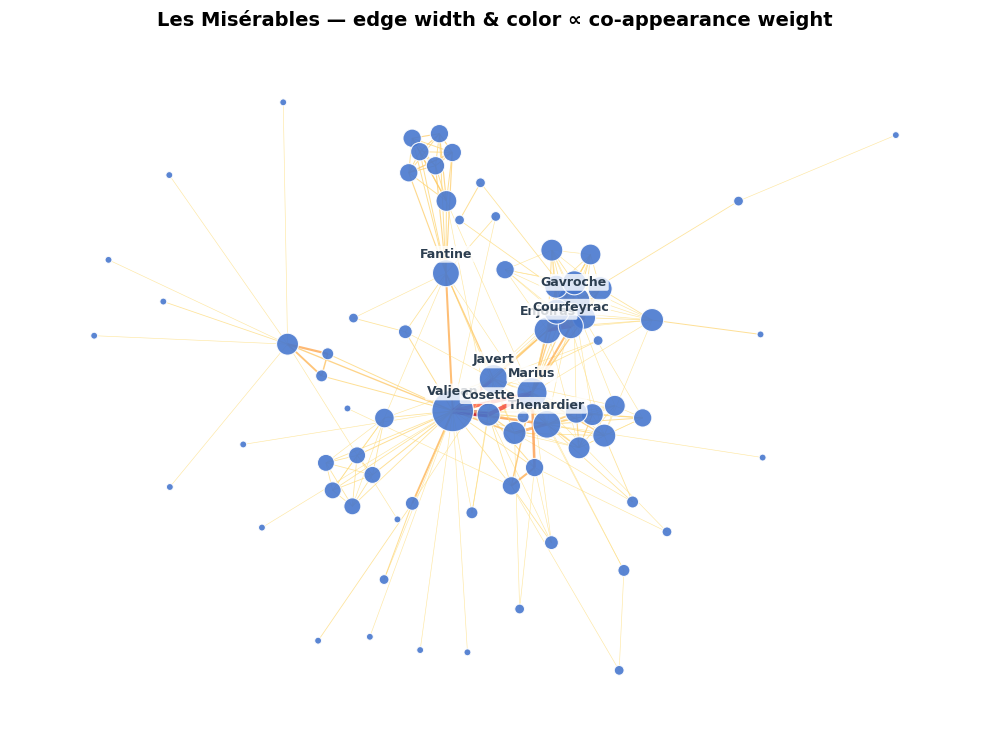

In [21]:
# Edge width & color ∝ weight — thicker/darker = more co-appearances
viz.draw_weighted_graph(
    G_les,
    title="Les Misérables — edge width & color ∝ co-appearance weight",
)

**Edge weights encode relationship strength.** Thicker lines connect characters who appear together more often. Notice how central characters form a dense weighted core — Valjean and Cosette share the strongest connection (weight 31), followed by Cosette–Marius and Valjean–Marius. The revolutionary group (Enjolras, Courfeyrac) and the Valjean–Javert rivalry also form dense weighted clusters, reflecting the plot's central relationships.

**What to notice**: Valjean dominates the layout — his node is the largest because he co-appears with more characters than anyone else. He is the network's **hub**. The smaller clusters around him correspond to different subplots of the novel (the Thénardiers, the students at the barricade, the Bishop's household). We will learn to detect these clusters automatically in Week 5.

---
## 4. Real-World Network: Zachary's Karate Club

In the 1970s, sociologist Wayne Zachary studied a university karate club for two years.
During his study, a conflict arose between the instructor (node 0) and the club president (node 33),
and the club eventually split into two factions.

This is one of the most famous datasets in network science — let's explore it.

In [22]:
G_karate = load_graph("karate")
graph_summary(G_karate)

karate: 34 nodes, 78 edges (undirected)
Graph Summary: Zachary's Karate Club
  Type:        undirected
  Nodes:       34
  Edges:       78
  Density:     0.1390
  Avg degree:  4.59
  Components:  1
  Avg clustering: 0.5706


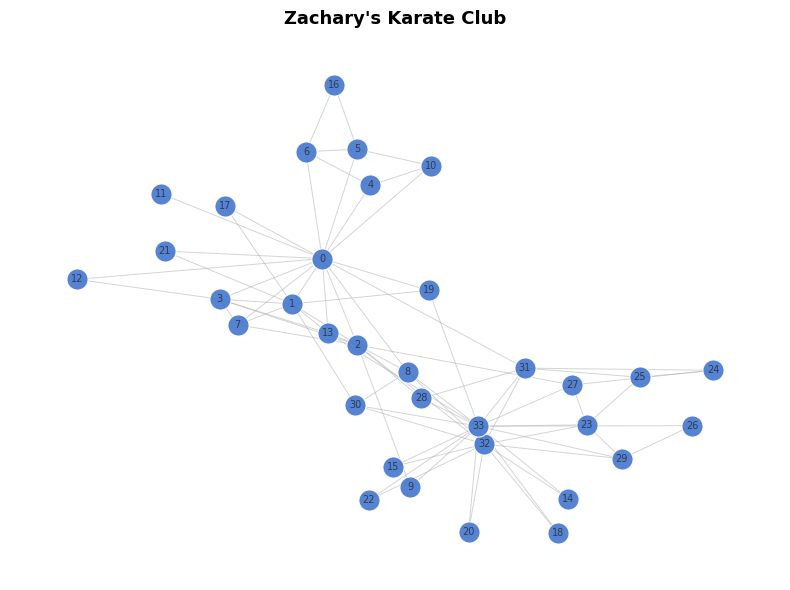

In [23]:
viz.draw_graph(G_karate, title="Zachary's Karate Club")

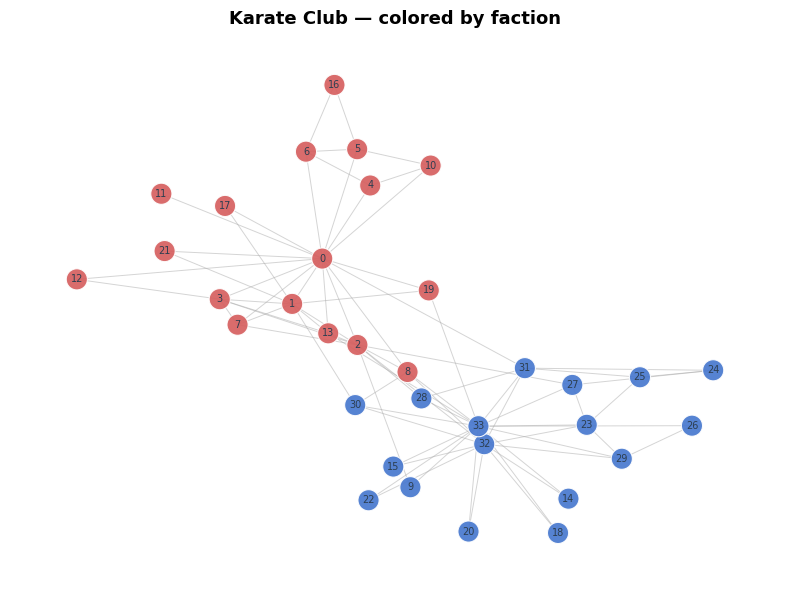

In [24]:
# Color each node by the faction it joined after the club split
color_map = []
for node in G_karate.nodes():
    club = G_karate.nodes[node].get("club", "Mr. Hi")
    color_map.append("#D65F5F" if club == "Mr. Hi" else "#4878CF")

viz.draw_graph(G_karate, node_color=color_map, title="Karate Club — colored by faction")

**Interpreting the factions**: Node 0 (the instructor) and node 33 (the president) are the two highest-degree nodes — they serve as the "centers" of their respective factions. Most members connect primarily within their own faction, but a few **bridge nodes** (like nodes 2 and 8) have connections to both sides. These bridges are exactly the members whose allegiance was hardest to predict during the real split.

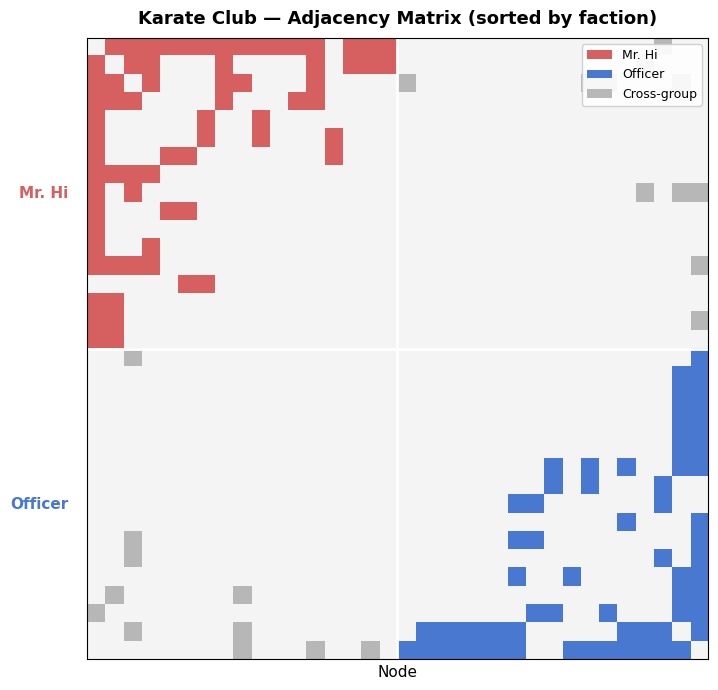

In [25]:
# Sort nodes by faction so block-diagonal structure is visible
mr_hi = sorted(n for n in G_karate if G_karate.nodes[n].get("club") == "Mr. Hi")
officer = sorted(n for n in G_karate if G_karate.nodes[n].get("club") == "Officer")
faction_order = mr_hi + officer

viz.plot_adjacency(
    G_karate,
    title="Karate Club — Adjacency Matrix (sorted by faction)",
    nodelist=faction_order,
    group_labels=[("Mr. Hi", len(mr_hi)), ("Officer", len(officer))],
)

We sorted nodes by faction (Mr. Hi first, then Officer) so the **block-diagonal structure** jumps out: the two dense squares along the diagonal are intra-faction edges, while the sparser off-diagonal regions are cross-faction connections. The colored sidebar on the left shows which group each row belongs to, and the dashed line marks the boundary. This foreshadows the **community detection** topic in Week 5.

---
## 5. Exploring with NetworkX

NetworkX provides many functions to query a graph. Let's try a few essential ones.

In [26]:
# Degree = number of edges attached to a node
print("Degree of node 0 (instructor):", G_karate.degree(0))
print("Degree of node 33 (president):", G_karate.degree(33))

print()

# Neighbors = the set of nodes directly connected by an edge
print("Neighbors of node 0:", list(G_karate.neighbors(0)))

Degree of node 0 (instructor): 16
Degree of node 33 (president): 17

Neighbors of node 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]


In [32]:
# Shortest path = fewest hops between two nodes
path = nx.shortest_path(G_karate, source=5, target=30)

print(f"Shortest path from node 1 to node 32: {path}")
print(f"Path length: {len(path) - 1} edges")

Shortest path from node 1 to node 32: [5, 0, 1, 30]
Path length: 3 edges


**Try it yourself**: In the cell below, try pairs from opposite factions (e.g., source=5, target=30 or source=1, target=32). Do cross-faction paths tend to be longer than within-faction paths? What is the shortest a cross-faction path can be?

In [33]:
# ---- TWEAK: Pick two different nodes and find the shortest path ----
source_node = 5  # <-- change me
target_node = 30  # <-- change me

path = nx.shortest_path(G_karate, source=source_node, target=target_node)
print(f"Shortest path from {source_node} to {target_node}: {path}")
print(f"Path length: {len(path) - 1} edges")

Shortest path from 5 to 30: [5, 0, 1, 30]
Path length: 3 edges


**What you should see**: Within-faction pairs (e.g., 0→1, 33→31) typically have paths of length 1-2. Cross-faction pairs often require 2-3 hops — they must pass through one of the bridge nodes or through the two leaders. The diameter of this small network is only 5, so even the most distant pair is surprisingly close.

---
## 6. Tweak & Observe: Layouts and Degree Distribution

The way we draw a graph is a *choice* — the same graph can look very different with different layout algorithms.

**Predict before you run**: Do you think different layout algorithms will preserve the two-faction structure equally well? A **spring layout** simulates physical forces (connected nodes attract), **Kamada-Kawai** minimizes stress in distances, and **circular** simply arranges nodes in a ring. Which one do you expect to show the factions most clearly?

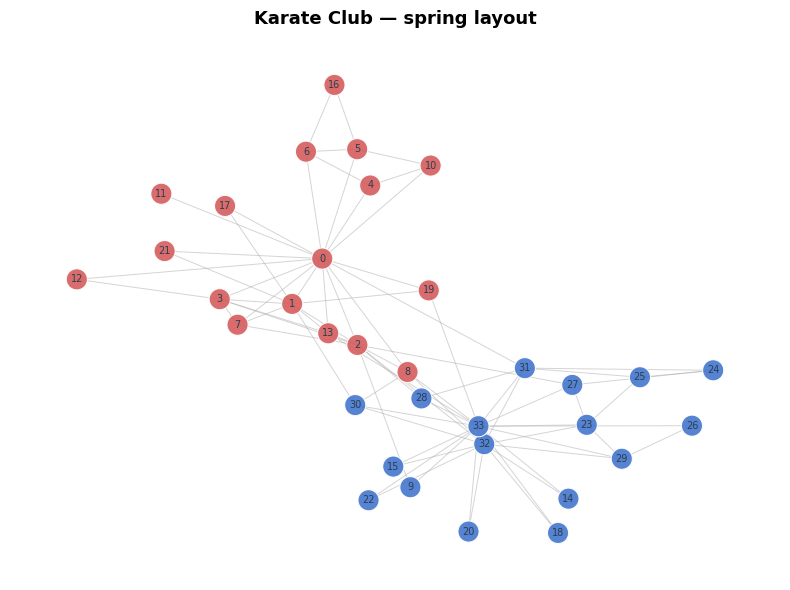

In [34]:
# ---- TWEAK: Try different layouts ----
layout = "spring"  # <-- change me: "spring", "kamada_kawai", or "circular"

viz.draw_graph(
    G_karate,
    node_color=color_map,
    layout=layout,
    title=f"Karate Club — {layout} layout",
)

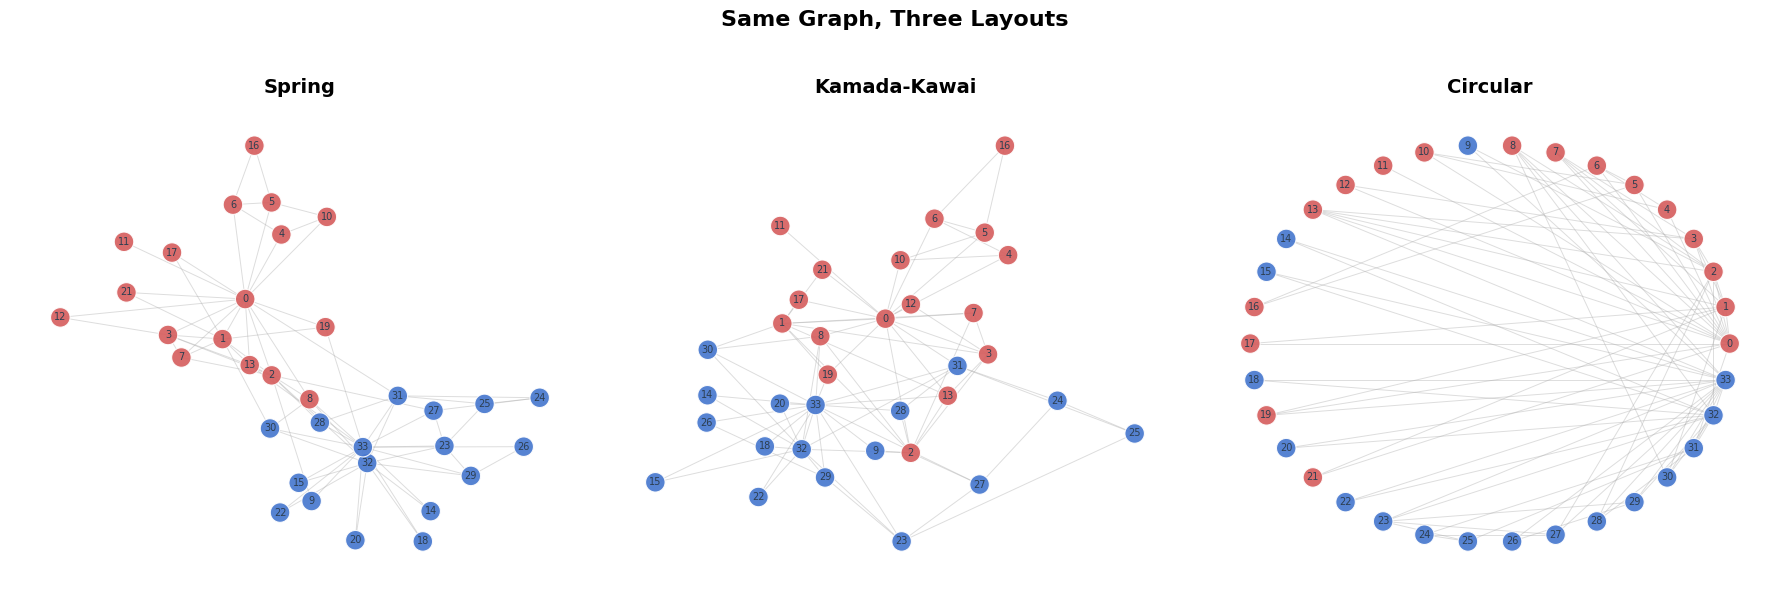

In [35]:
# Compare three layout algorithms on the same graph
viz.compare_layouts(G_karate, node_color=color_map, title="Same Graph, Three Layouts")

**Layouts compared**: Spring and Kamada-Kawai both pull the two factions apart — connected nodes cluster together, revealing the community structure. The circular layout obscures this structure because it ignores connectivity. The takeaway: **layouts are visualizations, not measurements** — they can suggest structure but never prove it. For rigorous community detection, we will use algorithms in Week 5.

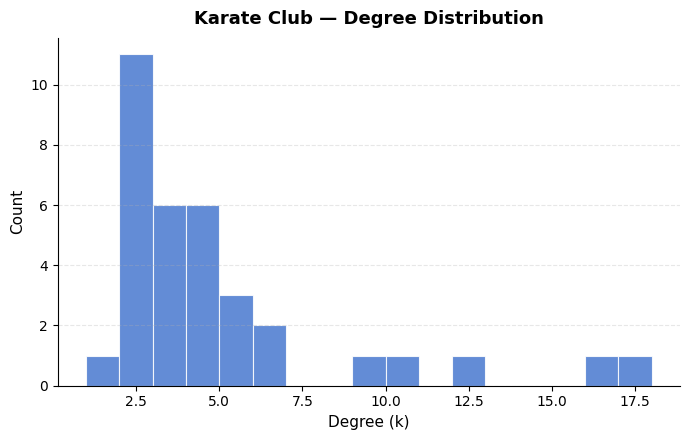

In [36]:
viz.plot_degree_dist(G_karate, title="Karate Club — Degree Distribution")

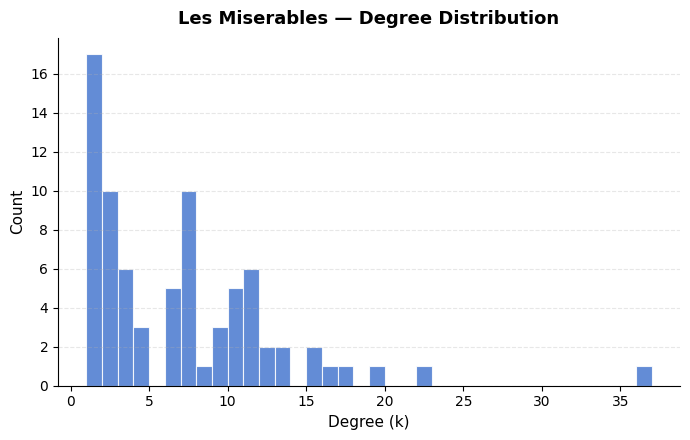

In [37]:
viz.plot_degree_dist(G_les, title="Les Miserables — Degree Distribution")

Both distributions are **right-skewed** — most nodes have few connections, but a few "stars" (Valjean in Les Mis, the instructor and president in Karate) have many. This pattern appears in almost every real-world network.

**Try it yourself**: Find the node with the highest degree in the Karate Club using a one-liner. Fill in the cell below and run it to check.

In [41]:
# YOUR CODE HERE — find the node with the highest degree using max()
highest_degree_node = max(G_karate.nodes, key=G_karate.degree)

assert highest_degree_node == 33, (
    "Hint: use max() with a key function that returns the degree of each node"
)
print(
    f"Node {highest_degree_node} has the highest degree: {G_karate.degree(highest_degree_node)}"
)

Node 33 has the highest degree: 17


**Looking ahead**: Why do so many real networks have this skewed "few hubs, many leaves" pattern? In Week 4 we will discover that a simple mechanism — **preferential attachment** ("the rich get richer") — naturally produces these fat-tailed degree distributions.

---
## Summary

In this lab we learned:

| Concept | Key idea |
|---------|----------|
| **Node & edge** | The building blocks of every network |
| **Undirected vs directed** | Facebook (mutual) vs Twitter (one-way) |
| **In-degree vs out-degree** | Popularity vs activity in directed networks |
| **Weakly vs strongly connected** | Ignoring vs respecting edge direction |
| **Weighted edges** | Edges can carry strength or frequency |
| **Bipartite networks** | Two node types, edges only cross types |
| **Degree** | Number of connections a node has |
| **Shortest path** | Fewest hops between two nodes |
| **Degree distribution** | How degrees are spread across the network |

Next week we will dive deeper into **network properties** — centrality, clustering, and what makes some nodes more important than others.